In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import urllib.request
import os

ModuleNotFoundError: No module named 'torch'

In [3]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118


Looking in indexes: https://download.pytorch.org/whl/cu118


In [2]:
if torch.cuda.is_available():
    print(f"Number of GPUs available: {torch.cuda.device_count()}")
    print(f"Current GPU: {torch.cuda.current_device()}")
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU is available.")

NameError: name 'torch' is not defined

In [2]:
!nvidia-smi

Mon Sep  8 10:32:40 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.85                 Driver Version: 555.85         CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 2060 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
| 29%   39C    P8             16W /  159W |     840MiB /   8192MiB |      9%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [7]:
from torchvision.datasets import FashionMNIST
from torchvision.transforms import ToTensor

In [8]:
training_data = FashionMNIST(
    root = 'data' ,
    train = True , 
    download = True , 
    transform = ToTensor()
)
test_data = FashionMNIST(
    root = "data",
    train = False,
    download = True,
    transform = ToTensor())

In [9]:
print(training_data)
print(training_data[0])

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()
(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 

In [10]:
print(test_data)
print(test_data[0])

Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: ToTensor()
(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0

In [11]:
sample = training_data[0]
image, label = sample

print(f"Image dimensions: {image.shape}")

print(f"Image data type: {image.dtype}")

print(f"Label: {label}")

print(f"Label data type: {type(label)}")



Image dimensions: torch.Size([1, 28, 28])
Image data type: torch.float32
Label: 9
Label data type: <class 'int'>


In [12]:
print(training_data[0][0].shape)

torch.Size([1, 28, 28])


In [13]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}

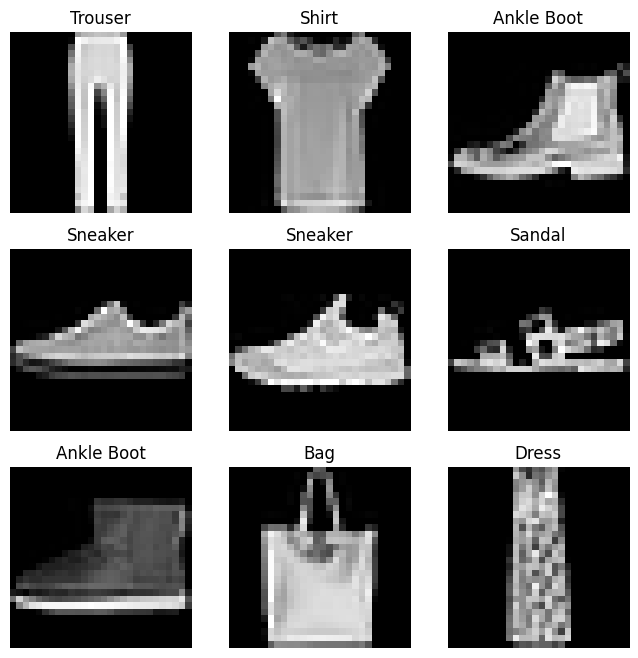

In [14]:
figure = plt.figure(figsize=(8,8))

rows, cols =3, 3

for i in range(1, rows * cols + 1):
    sample_idx =torch.randint(len(training_data), size=(1,)).item()
    
    img, label = training_data[sample_idx]

    figure.add_subplot(rows, cols, i)

    plt.title(labels_map[label])

    plt.axis("off")

    plt.imshow(img.squeeze(), cmap = "gray")

plt.show()

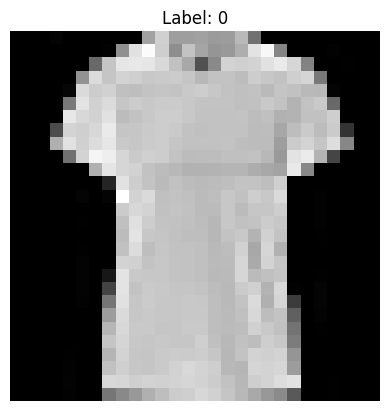

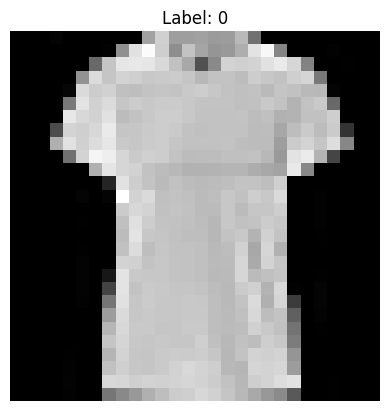

In [15]:
sample = training_data[66]
image, label = sample

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")  
plt.show()
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")  
plt.show()


torch.Size([32, 1, 28, 28])
torch.Size([32])
tensor([2, 8, 4, 5, 9, 1, 6, 2, 0, 4, 0, 3, 5, 1, 1, 9, 5, 5, 0, 0, 9, 7, 1, 6,
        4, 5, 1, 3, 5, 8, 8, 5])
torch.Size([28, 28])


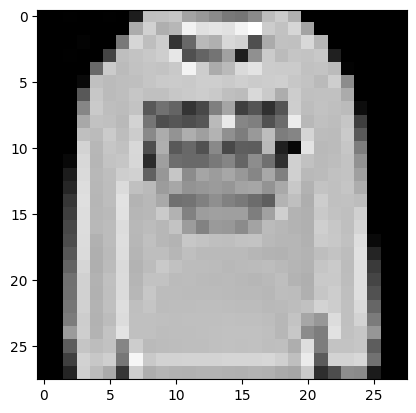

In [16]:
training_dataloader = DataLoader(training_data, batch_size = 32, shuffle = True)
test_dataloader = DataLoader(test_data, batch_size = 32, shuffle = True)

batch_features, batch_labels = next(iter(training_dataloader))

sample = batch_features[0].squeeze()

print(batch_features.shape)
print(batch_labels.shape)
print(batch_labels)
print(batch_features[0].squeeze().shape)

plt.imshow(sample ,cmap='gray')

In [17]:
url_train = "https://raw.githubusercontent.com/fpleoni/fashion_mnist/master/fashion-mnist_train.csv"
url_test  = "https://raw.githubusercontent.com/fpleoni/fashion_mnist/master/fashion-mnist_test.csv"

train_csv = "fashion_train.csv"
test_csv  = "fashion_test.csv"

if not os.path.exists(train_csv):
    urllib.request.urlretrieve(url_train, train_csv)
if not os.path.exists(test_csv):
    urllib.request.urlretrieve(url_test, test_csv)


data_train = pd.read_csv(train_csv, header=None, skiprows=1)
data_test  = pd.read_csv(test_csv, header=None, skiprows=1)

print("Train shape:", data_train.shape)
print("Test shape:", data_test.shape)

Train shape: (2, 1)
Test shape: (2, 1)


In [18]:
class CustomDataset(Dataset):
    def __init__(self, dataframe):

        self.img = dataframe.iloc[:, 1:].values
        self.label = dataframe.iloc[:, 0].values

    def __len__(self):
        return len(self.label)

    def __getitem__(self, index):
        image = self.img[index].astype(np.float32).reshape(28, 28) / 255.0  
        label = int(self.label[index])
        return torch.tensor(image).unsqueeze(0), torch.tensor(label)

In [19]:
train_dataset = CustomDataset(data_train)
test_dataset  = CustomDataset(data_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)